# Multi-Layer Network Visualization

This notebook demonstrates how to use the `multi_layer_NetViz_fcts` library to create a 3D visualization of a multi-layer network.

In [1]:
import os
import pickle
import numpy as np
import polars as pl
import networkx as nx
import matplotlib.pyplot as plt
from multi_layer_NetViz_fcts import (
    Layer,
    LayeredNetworkGraph,
    compute_node_colors,
    create_ellipse_marker,
    create_parallelogram_marker,
    adjacency_to_edges,
    node_activity,
    top_k_partners,
)


# Core example

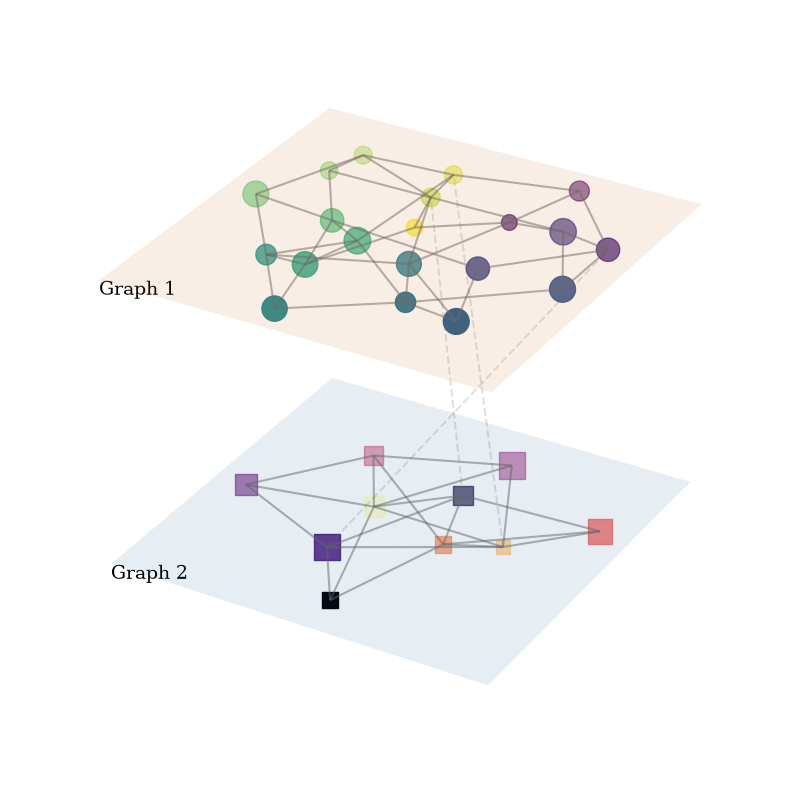

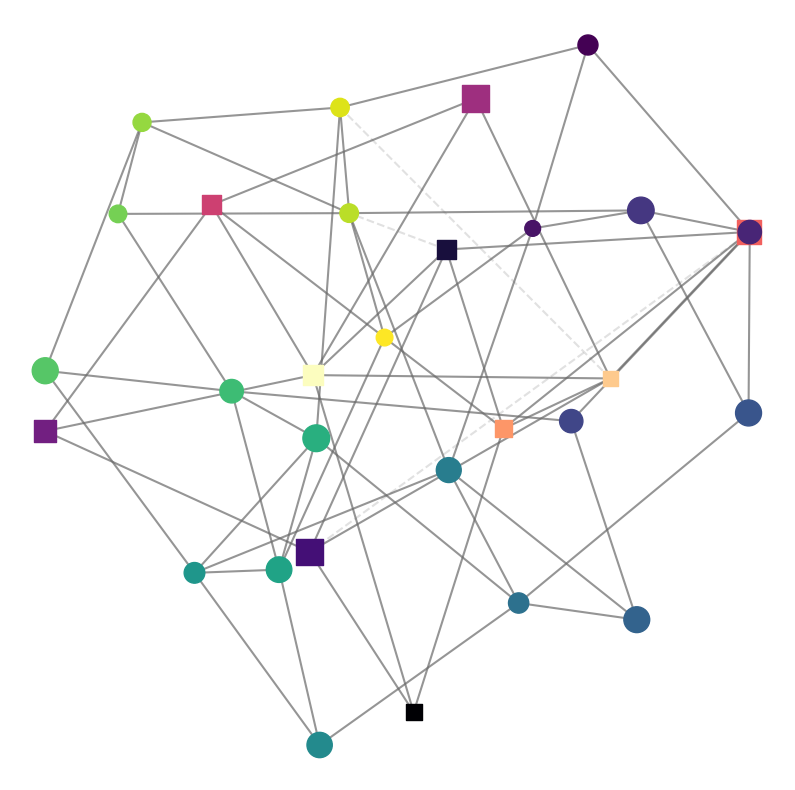

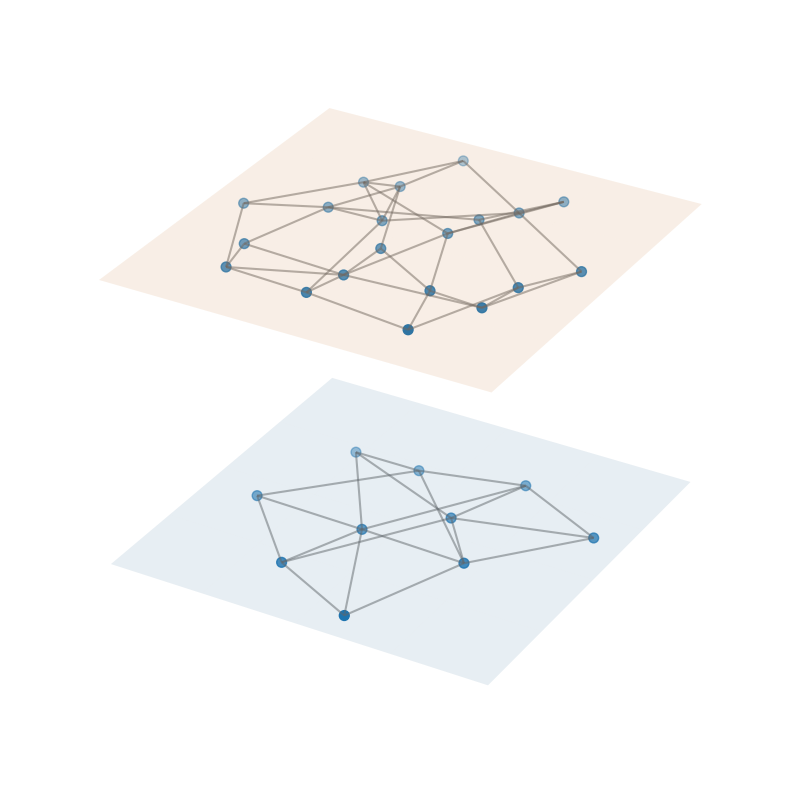

In [2]:
graph_1 = nx.watts_strogatz_graph(20, 4, 0.2, seed=42)
graph_2 = nx.watts_strogatz_graph(10, 4, 0.2, seed=43)

# add random sizes and colors
node_sizes_g1 = np.random.rand(20) * 300 + 100
node_sizes_g2 = np.random.rand(10) * 300 + 100
g1_colors = [plt.cm.viridis(x) for x in np.linspace(0, 1, 20)]
g2_colors = [plt.cm.magma(x) for x in np.linspace(0, 1, 10)]

# define layers
layer_g1 = Layer(graph_1, z_pos=1, label='Graph 1', layout=nx.spring_layout,
                 node_size=node_sizes_g1, node_color=g1_colors, node_marker='o', node_2d_marker='o')
layer_g2 = Layer(graph_2, z_pos=0, label='Graph 2', layout=nx.spring_layout,
                 node_size=node_sizes_g2, node_color=g2_colors, node_marker='s', node_2d_marker='s')

# define some interlayer edges (for demonstration, connect each node in graph 2 to 2 random nodes in graph 1)
rand_nodes_g1 = np.random.choice(20, 3, replace=False)
rand_nodes_g2 = np.random.choice(10, 3, replace=False)
interlayer_edges = [(i, j, 0, 1) for i, j in zip(rand_nodes_g2.flatten(), rand_nodes_g1.flatten())]

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
vis = LayeredNetworkGraph(layers=[layer_g2, layer_g1], interlayer_edges=interlayer_edges, ax=ax)
vis.draw()
ax.grid(False)
ax.set_axis_off()
# plt.savefig('example_multilayer_network.pdf', bbox_inches='tight'
plt.show()

# 2D visualization

fig, ax = plt.subplots(figsize=(10, 10))
vis.draw_2d(ax=ax, interlayer_edges_2d=interlayer_edges)
plt.show()

# without interlayer edges and customizations

layer_g1 = Layer(graph_1)
layer_g2 = Layer(graph_2)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
vis = LayeredNetworkGraph(layers=[layer_g2, layer_g1], ax=ax)

vis.draw()
ax.grid(False)
ax.set_axis_off()
plt.show()


## Load Data

Load the example data from the `url_params.pkl` file. This file contains the parameters for a two-layer network.

In [3]:
with open(os.path.join(os.getcwd(), 'params_url', 'url_params.pkl'), 'rb') as f:
    dict_url = pickle.load(f)

N1 = dict_url['N1']
N2 = dict_url['N2']
adj_g1 = dict_url['adj_g1']
adj_g2 = dict_url['adj_g2']
num_eve_g1_g2 = dict_url['num_eve_g1_g2']
cross_g1_g2 = dict_url['cross_g1_g2']
exp_coeff = dict_url['exp_coeff']
hours = dict_url['hours']

# Tabular views of the dense matrices (Polars, not pandas)
events = pl.DataFrame(num_eve_g1_g2)
cross = pl.DataFrame(cross_g1_g2)
edges_g2 = adjacency_to_edges(adj_g2, threshold=1e-1)
edges_g2.head()


source,target,weight
i64,i64,f64
0,1,0.252
0,2,0.225
0,5,0.242
1,0,0.333
1,2,0.325


## Define Network Layers

Create the two layers of the network using the `Layer` class. The first layer represents topics, and the second layer represents users.

In [6]:
g1 = nx.from_numpy_array(adj_g1)
g2 = nx.from_numpy_array(adj_g2)

# Layer 1: Topics
topic_activity = node_activity(num_eve_g1_g2, axis="columns")
user_activity = node_activity(num_eve_g1_g2, axis="rows")
node_sizes_g2 = topic_activity["activity"].to_numpy() ** 0.8
node_labels_g2 = {nn: str(nn) for nn in range(N2)}
edge_labels_g2 = {
    (row["source"], row["target"]): f"{row['weight']:.2f}"
    for row in edges_g2.iter_rows(named=True)
}
parallelogram_marker = create_parallelogram_marker(angle_deg=45)
node_markers_g2 = [parallelogram_marker] * N2
node_2d_marker = ['s'] * N2  # square marker for 2D plotting
edge_arrows_g2 = [
    (row["source"], row["target"], row["weight"] > 1e-3)
    for row in edges_g2.iter_rows(named=True)
]

# Layer 2: Users
node_sizes_g1 = user_activity["activity"].to_numpy() ** 0.9
ellipse_marker = create_ellipse_marker(angle_deg=-5)
node_markers_g1 = [ellipse_marker] * N1
node_2d_marker_g1 = ['o'] * N1  # circle marker for 2D plotting

# Alignment and colors (dense linear algebra stays in NumPy)
alignment_g1_g2 = np.exp(exp_coeff * num_eve_g1_g2 @ adj_g2 / hours) / np.sum(np.exp(exp_coeff * num_eve_g1_g2 @ adj_g2 / hours), axis=1)[:, None]
g1_colors, g2_colors = compute_node_colors(alignment_g1_g2)

# Layouts
seed = 304
layout_g2 = nx.spring_layout(g2, scale=1, seed=seed)
lay_g2_array = np.array([layout_g2[key] for key in range(N2)])
g1_pos = np.dot(alignment_g1_g2, lay_g2_array)
layout_g1_spring = nx.spring_layout(g1, scale=1, seed=seed)
lay_g1_array = np.array([layout_g1_spring[key] for key in range(N1)])
alpha = 0.7
g1_positions = alpha * g1_pos + (1 - alpha) * lay_g1_array
final_layout_g1 = {i: g1_positions[i] for i in range(N1)}

layer1 = Layer(g2, z_pos=0, label=r'$\mathbf{Topics \ (\Sigma)}$', layout=lambda g: layout_g2,
               node_size=node_sizes_g2, node_color=g2_colors, node_label=node_labels_g2, node_marker=node_markers_g2, node_2d_marker=node_2d_marker,
               edge_label=edge_labels_g2,edge_alpha=np.linspace(0.3,1,len(g2.edges())), edge_arrows=edge_arrows_g2)

layer2 = Layer(g1, z_pos=1, label=r'$\mathbf{Users \ (W)}$', layout=lambda g: final_layout_g1,
               node_size=node_sizes_g1, node_color=g1_colors, node_marker=node_markers_g1, node_2d_marker=node_2d_marker_g1, node_alpha=np.linspace(0.5,1,N1))


## Create and Draw the Multi-Layer Network

Now, create an instance of `LayeredNetworkGraph` and draw the network. We also define the interlayer edges.

In [7]:
# reload the module to reflect recent changes
from importlib import reload
import multi_layer_NetViz_fcts
reload(multi_layer_NetViz_fcts)
from multi_layer_NetViz_fcts import *

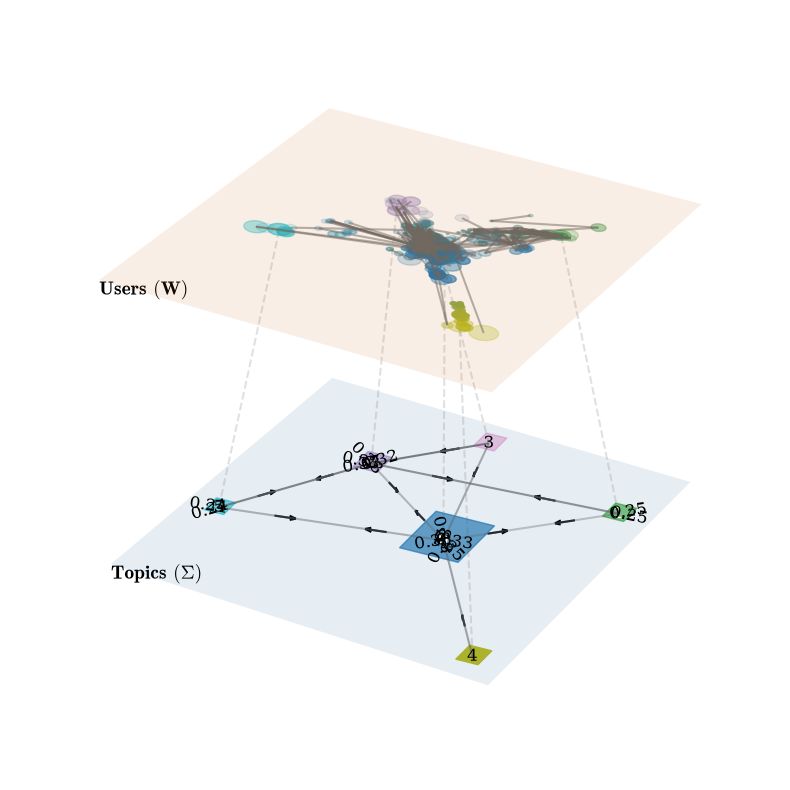

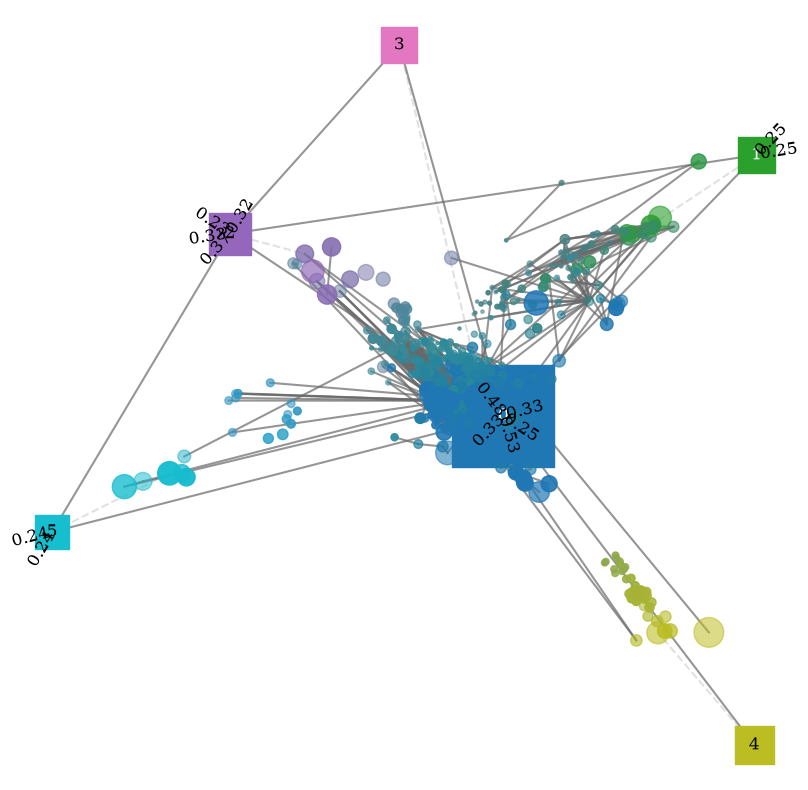

In [8]:
k = 1
partners = top_k_partners(cross_g1_g2, k=k, row_name="user", col_name="topic")
interlayer_edges = [
    (row["topic"], row["user"], 0, 1)
    for row in partners.iter_rows(named=True)
]

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

vis = LayeredNetworkGraph(layers=[layer1, layer2], interlayer_edges=interlayer_edges, ax=ax)
vis.draw()
ax.grid(False)
ax.set_axis_off()
plt.show()

fig, ax = plt.subplots(figsize=(10, 10))
vis.draw_2d(ax=ax, interlayer_edges_2d=interlayer_edges)
plt.show()


## Temporal Network Evolution Example

This example showcases how to visualize the evolution of a network over time, where each layer represents a snapshot of the network at a specific timestamp.

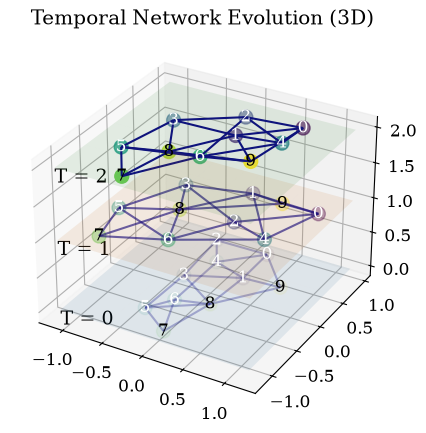

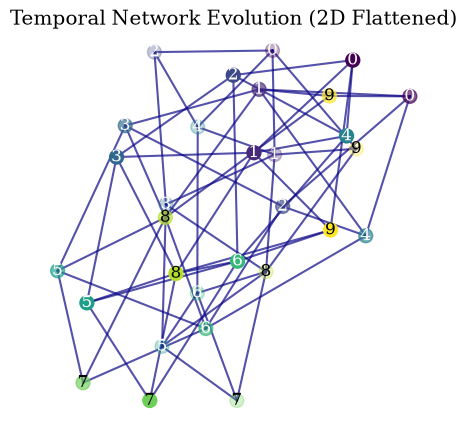

In [9]:
# 1. Generate a sequence of graphs
num_timestamps = 3
base_graph = nx.watts_strogatz_graph(10, 4, 0.2, seed=42)
temporal_graphs = [base_graph]
layouts = [nx.spring_layout(base_graph, seed=42)]
for i in range(1, num_timestamps):
    g = temporal_graphs[-1].copy()
    # Add or remove an edge
    if np.random.rand() > 0.5 and len(g.edges) > 0:
        g.remove_edge(*list(g.edges())[np.random.randint(len(g.edges))])
    else:
        nodes = list(g.nodes())
        u, v = np.random.choice(nodes, 2, replace=False)
        if not g.has_edge(u, v):
            g.add_edge(u, v)
    temporal_graphs.append(g)
    layouts.append(nx.spring_layout(g, seed=42))

# 2. Create layers
layers = []
node_colors = plt.cm.viridis(np.linspace(0, 1, len(base_graph.nodes())))
edge_colors = plt.cm.plasma(np.linspace(0, 1, num_timestamps))
pos_layout = nx.spring_layout(base_graph, seed=42) # Fix layout for consistency
node_label = {nn: str(nn) for nn in range(len(base_graph.nodes()))}
alpha_vals = np.linspace(0.3, 1, num_timestamps)
for i, g in enumerate(temporal_graphs):
    layer = Layer(g, z_pos=i, label=f'T = {i}',
                  layout=lambda g, pos=layouts[i]: pos,
                  node_color=node_colors,
                  edge_color=edge_colors[0],
                  node_label=node_label,
                  node_size=100,
                  node_alpha=alpha_vals[i],
                  edge_alpha=alpha_vals[i])
    layers.append(layer)

# 3. Create interlayer edges
interlayer_edges = []
# for i in range(num_timestamps - 1):
#     for node in temporal_graphs[i].nodes():
#         if node in temporal_graphs[i+1].nodes():
#             interlayer_edges.append((node, node, i, i+1))

# 4. Visualize in 3D
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')
vis_temporal = LayeredNetworkGraph(layers=layers, interlayer_edges=interlayer_edges, ax=ax)
vis_temporal.draw()
plt.title("Temporal Network Evolution (3D)")
plt.show()

# 5. Visualize in 2D
fig, ax = plt.subplots(figsize=(5, 5))
vis_temporal.draw_2d(ax=ax)
plt.title("Temporal Network Evolution (2D Flattened)")
plt.show()

In [10]:
# reload the module to reflect recent changes
from importlib import reload
import multi_layer_NetViz_fcts
reload(multi_layer_NetViz_fcts)
from multi_layer_NetViz_fcts import *

In [11]:
g1 = nx.from_numpy_array(adj_g1)
g2 = nx.from_numpy_array(adj_g2)

# Layer 1: Topics
num_eve_g2 = np.sum(num_eve_g1_g2, axis=0)
node_sizes_g2 = num_eve_g2**0.8
node_labels_g2 = {nn: str(nn) for nn in range(N2)}
edge_labels_g2 = {(p1, p2): f'{adj_g2[p1, p2]}' for p1 in range(N2) for p2 in range(N2) if p1 != p2 and adj_g2[p1, p2] > 1e-1}
parallelogram_marker = create_parallelogram_marker(angle_deg=45)
node_markers_g2 = [parallelogram_marker] * N2
node_2d_marker = ['s'] * N2  # square marker for 2D plotting

# Layer 2: Users
num_eve_g1 = np.sum(num_eve_g1_g2, axis=1)
node_sizes_g1 = num_eve_g1**0.9
ellipse_marker = create_ellipse_marker(angle_deg=-5)
node_markers_g1 = [ellipse_marker] * N1
node_2d_marker_g1 = ['o'] * N1  # circle marker for 2D plotting

# Alignment and colors
alignment_g1_g2 = np.exp(exp_coeff * num_eve_g1_g2 @ adj_g2 / hours) / np.sum(np.exp(exp_coeff * num_eve_g1_g2 @ adj_g2 / hours), axis=1)[:, None]
g1_colors, g2_colors = compute_node_colors(alignment_g1_g2)

# Layouts
seed = 304
layout_g2 = nx.spring_layout(g2, scale=1, seed=seed)
lay_g2_array = np.array([layout_g2[key] for key in range(N2)])
g1_pos = np.dot(alignment_g1_g2, lay_g2_array)
layout_g1_spring = nx.spring_layout(g1, scale=1, seed=seed)
lay_g1_array = np.array([layout_g1_spring[key] for key in range(N1)])
alpha = 0.7
g1_positions = alpha * g1_pos + (1 - alpha) * lay_g1_array
final_layout_g1 = {i: g1_positions[i] for i in range(N1)}

layer1 = Layer(g2) #, z_pos=0, label=r'$\mathbf{Topics \ (\Sigma)}$', layout=lambda g: layout_g2,
            #    node_size=node_sizes_g2, node_color=g2_colors, node_label=node_labels_g2, node_marker=node_markers_g2, node_2d_marker=node_2d_marker,
            #    edge_label=edge_labels_g2,edge_alpha=np.linspace(0.3,1,len(g2.edges())))

layer2 = Layer(g1) #, z_pos=1, label=r'$\mathbf{Users \ (W)}$', layout=lambda g: final_layout_g1,
               #    node_size=node_sizes_g1, node_color=g1_colors, node_marker=node_markers_g1, node_2d_marker=node_2d_marker_g1, node_alpha=np.linspace(0.5,1,N1))

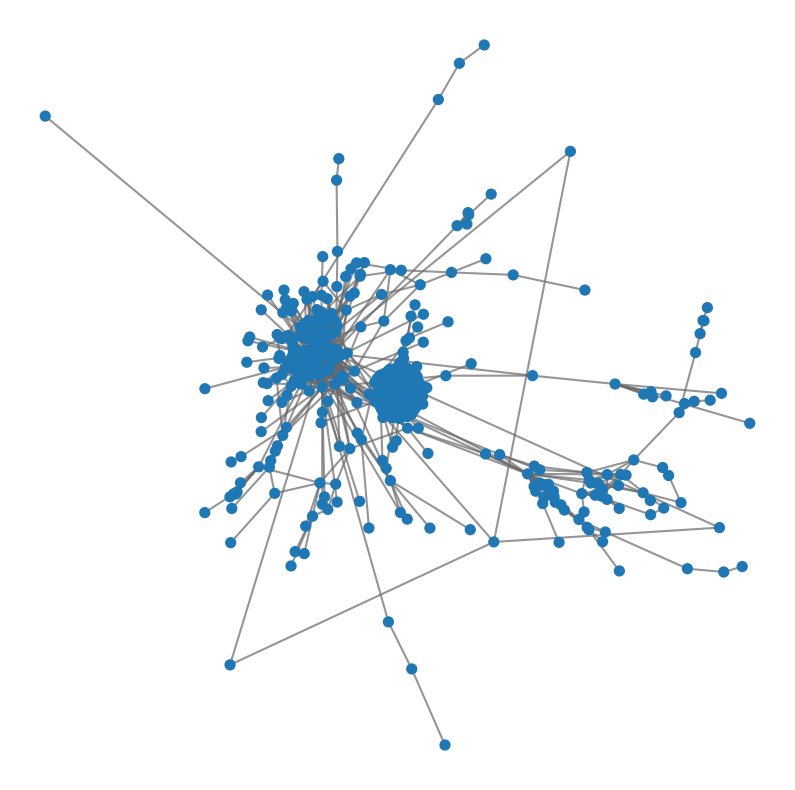

In [13]:
vis = LayeredNetworkGraph(layers=[layer1, layer2])
if vis.ax is not None:
    plt.close(vis.ax.get_figure())
vis.draw_2d()


# Non-Core Example

In [14]:
from pathlib import Path
import pickle
with Path("D:/Code/MultiLayerNetViz/resources/data/multilayer_network.pkl").open("rb") as f:
    payload = pickle.load(f)
G = payload["graph"]
multilayer_index = payload["index"]
window = payload["window"]
print(G, multilayer_index, window)

Graph with 540 nodes and 3076 edges -10 ('2025-04-08', '2025-09-26')


In [15]:
from importlib import reload
import io

from IPython.display import Image, display
from matplotlib.figure import Figure

import multi_layer_NetViz_fcts
reload(multi_layer_NetViz_fcts)
from multi_layer_NetViz_fcts import plot_multilayer_netviz as _plot_multilayer_netviz


def _display_fig(fig: Figure) -> None:
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=130, bbox_inches="tight", pad_inches=0.08, facecolor="white")
    buf.seek(0)
    display(Image(data=buf.getvalue()))


def plot_multilayer_netviz(*args, **kwargs):
    """Reload-safe wrapper: always uses the on-disk library styling."""
    fig, ax = _plot_multilayer_netviz(*args, **kwargs)
    _display_fig(fig)
    return fig, ax


In [ ]:
terms_keep = ["Y000p5", "Y001p0", "Y002p0"]
G_full = G
G_small = G_full.subgraph(
    [n for n in G_full.nodes() if isinstance(n, tuple) and n[1] in terms_keep]
).copy()
fig, ax = plot_multilayer_netviz(G_small, terms_keep)
fig